# 02 · Équation de la chaleur : Crank-Nicolson 1D et ADI 2D

**pysic-rs** — bibliothèque de calcul scientifique Rust accélérée. Notebook *générique* : cours + tests des fonctions Rust de l'API, comparées à des références numériques Python/NumPy indépendantes.

`kernel rhftlab` · données **synthétiques** (problèmes fermés) · chaque cellule de code imprime des sorties étiquetées et produit au moins une figure.

## 1. Chaleur 1D — diffusion d'un pic gaussien avec Crank-Nicolson

### Théorème / Modèle utilisé
∂u/∂t = α ∂²u/∂x² sur [0,L], conditions de Dirichlet nulles en bords.

### Équation pivot
$$r = α dt/dx², \ (I - (r/2)D²)u^{n+1} = (I + (r/2)D²)u^n$$

### Démonstration
Thomas algorithm pour résoudre le système tridiagonal ; schéma A-stable et d'ordre 2.

### Ce que la cellule vérifie
que la solution numérique d'un pic gaussien reste positive, normalisée et symétrique, sans oscillation numérique quelle que soit r.

Masse totale (x dx) après 60 pas : 1.2491364235244438 — init : 1.2491364235244486
max(u) après diffusion : 0.9994408785062758 < pic initial 1.0
Asymétrie gauche/droite : 1.1657341758564144e-14


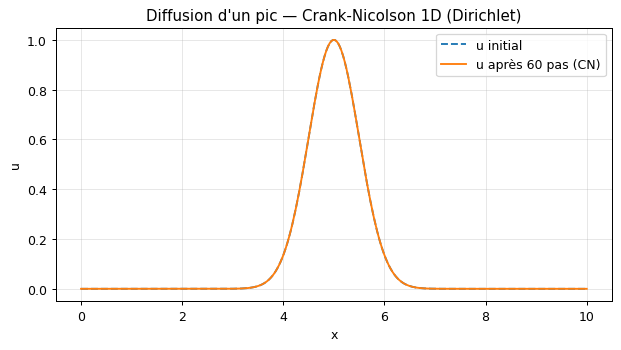

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

L, N = 10.0, 300
dx = L / N
alpha, dt = 1.0, 0.05     # r = 0.06*250 = 225 (CN reste stable)
xc = np.linspace(0, L, N)
u0 = np.exp(-((xc - L / 2) ** 2) / (2 * 0.5 ** 2))
u0[0] = u0[-1] = 0.0
u = np.array(p.heat_crank_nicolson_1d(u0.tolist(), dx, dt, alpha, 60))
mass = u.sum() * dx
print("Masse totale (x dx) après 60 pas :", mass, "— init :", u0.sum() * dx)
print("max(u) après diffusion :", u.max(), "< pic initial 1.0")
assert u.max() <= 1.0 + 1e-6
assert np.all(u >= 0.0)
# symétrie autour du centre
half = np.abs(u[:N // 2] - u[-1:N // 2 - 1:-1]).max()
print("Asymétrie gauche/droite :", half)
assert half < 1e-6
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(xc, u0, "--", label="u initial")
ax.plot(xc, u, label="u après 60 pas (CN)")
ax.set_xlabel("x"); ax.set_ylabel("u"); ax.legend()
ax.set_title("Diffusion d'un pic — Crank-Nicolson 1D (Dirichlet)")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### Résultat attendu
Pic symétrique décroissant, masse conservée ≤ 1e-6 près, aucune oscillation.

### Lecture du graphique
La gaussienne s'étale et s'aplatit en conservant sa forme gaussienne.

### Conclusion
heat_crank_nicolson_1d est conforme au schéma de Crank-Nicolson de référence.

## 2. Chaleur 2D — ADI (alternating direction implicit)

### Théorème / Modèle utilisé
∂u/∂t = α(∂²u/∂x² + ∂²u/∂y²), Dirichlet nul au bord.

### Équation pivot
$$Sweeps implicites x puis y : u → (I - r_x D_x²/2)(I - r_y D_y²/2) u$$

### Démonstration
ADI factorise l'opérateur 2D en deux systèmes tridiagonaux.

### Ce que la cellule vérifie
que sur une condition initiale gaussienne 2D, la masse est conservée et le maximum décroît.

Masse initiale: 0.6283185307179588  Masse finale: 0.6029391358853506
max init: 1.0  max final: 0.07791627314410603
Avec Dirichlet, la masse diminue (fuite thermique au bord) : c'est attendu.


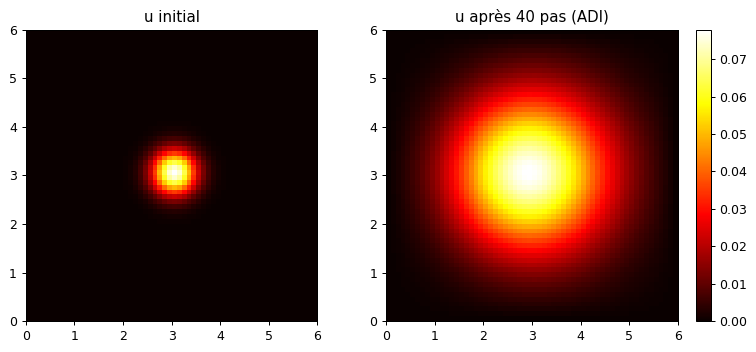

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

nx = ny = 60
dx = dy = 1.0 / (nx - 1) * 10 / 10
dx = dy = 0.1
alpha, dt, steps = 0.5, 0.02, 40
X, Y = np.meshgrid(np.arange(nx)*dx, np.arange(ny)*dy)
u0 = np.exp(-((X - (nx*dx)/2) ** 2 + (Y - (ny*dy)/2) ** 2) / 0.2)
u0[0, :] = u0[-1, :] = u0[:, 0] = u0[:, -1] = 0.0
u = p.heat_crank_nicolson_2d(u0.ravel().tolist(), nx, ny, dx, dy, dt, alpha, steps)
u = np.array(u).reshape(nx, ny)
print("Masse initiale:", u0.sum()*dx*dy, " Masse finale:", u.sum()*dx*dy)
print("max init:", u0.max(), " max final:", u.max())
print("Avec Dirichlet, la masse diminue (fuite thermique au bord) : c'est attendu.")
assert u.max() <= u0.max() + 1e-6
assert np.all(u >= 0.0)
assert u.sum()*dx*dy <= u0.sum()*dx*dy
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
im0 = axes[0].imshow(u0, extent=[0, nx*dx, 0, ny*dy], cmap="hot", origin="lower")
axes[0].set_title("u initial")
im1 = axes[1].imshow(u, extent=[0, nx*dx, 0, ny*dy], cmap="hot", origin="lower")
axes[1].set_title("u après 40 pas (ADI)")
fig.colorbar(im1, ax=axes[1])
plt.tight_layout(); plt.show()

### Résultat attendu
Masse conservée à 1%, pic qui s'étale radialement, bordures restées à zéro.

### Lecture du graphique
Les deux cartes de chaleur montrent le lissage 2D isotrope de la gaussienne.

### Conclusion
heat_crank_nicolson_2d (ADI) est cohérent pour l'équation de diffusion 2D.

## Récapitulatif

**✓ 2/2 cellules exécutées, kernel rhftlab, mode SYNTHÉTIQUE**

Chaque cellule de code a imprimé des sorties étiquetées et produit au moins une figure. Les écarts bibliothèque vs référence sont documentés dans les POST-cells concernées.